# Generate the result in RQ3

This script generates the results presented in the RQ3 section of the paper. The script reads the data from the `data/rq3-residual-risk` folder and generates the results presented in the paper. The figures are saved in the `figures` folder.

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import multiprocessing as mp
import re

# Directory where the coverage records are stored
directory = "data/rq3-residual-risk"
fig_dir = "figures"

## Helper functions

### Helper functions for parsing the coverage records

In [11]:
# Record class
# exec_per_time: the average number of executions per time unit during the
#                fuzzing campaign
# p_emp_min: the minimum value of the empirical discovery probability
# data_done: the coverage records
@dataclass
class Record:
    exec_per_time: float
    p_emp_min: float
    data_done: pd.DataFrame

# Parse the record file and return a Record object
def get_record_obj(data_path):
    data = pd.read_csv(data_path, sep=", ", engine="python")
    data["done"] = data["done"].astype(bool)
    data["time"] = data["time"] / 1000 / 60
    # if #singletons or #sglt_clusts is 0, set it to 1
    data["#singletons"] = data["#singletons"].replace(0, 1)
    data["#sglt_clusts"] = data["#sglt_clusts"].replace(0, 1)
    data_done = data[data["done"]]
    # cut off the data after 24 hours
    data_done = data_done[data_done["time"] < 24 * 60]
    row_last = data_done.iloc[-1]
    last_index = data_done.index[-1]
    # Add a row for 24 hours
    if last_index + 1 < len(data):
        row_last_plus1 = data.iloc[last_index + 1]
        row_24h = {
            "time": 24 * 60.0,
            "#execs": row_last["#execs"]
                + (row_last_plus1["#execs"] - row_last["#execs"])
                * (24 * 60 - row_last["time"])
                / (row_last_plus1["time"] - row_last["time"]),
            "#covered": row_last["#covered"],
            "#singletons": row_last["#singletons"],
            "#sglt_clusts": row_last["#sglt_clusts"],
            "#foundnew": row_last["#foundnew"],
            "done": True,
            "update?": False,
        }
        data_done = pd.concat(
            [data_done, pd.DataFrame([row_24h])], ignore_index=True
        )
    data_done.loc[:, "#execs"] = data_done["#execs"].astype(int)

    exec_per_time = data_done.iloc[-1]["#execs"] / data_done.iloc[-1]["time"]
    p_emps = data_done["#foundnew"] / data_done["#execs"]
    p_emps_min = np.min(p_emps[p_emps > 0])

    return Record(exec_per_time, p_emps_min, data_done)


# Given the time t_m, get the empirical discovery probability and
# the discovery probability estimated by the Good-Turing estimator (GT) and
# our dependenc-aware estimator (Chao)
def discovery(
    record_obj: Record, t_m: float, target: str, debug: bool = False
) -> float:
    exec_at_t = int(t_m * record_obj.exec_per_time)
    if exec_at_t == 0:
        return 0
    # find the row where #execs is the closest to exec_at_t
    for i, row in record_obj.data_done.iterrows():
        if row["#execs"] > exec_at_t:
            break
    row = record_obj.data_done.iloc[i - 1]
    assert row["done"]
    if debug:
        print(row)
    if target == "GT":
        ret = row["#singletons"] / exec_at_t
    elif target == "Chao":
        ret = row["#sglt_clusts"] / exec_at_t
    elif target == "emp":
        ret = row["#foundnew"] / exec_at_t
        if ret == 0:
            ret = record_obj.p_emp_min
    else:
        raise ValueError(f"Invalid target: {target}")
    return ret


# Get the analyzable format of the estimation results
def get_plot_df(
    record_obj: Record, x_scale: str, id: str
) -> pd.DataFrame:
    if x_scale == "lin":
        x = np.linspace(0, 24 * 60, 1000)
    elif x_scale == "log":
        x = np.logspace(0, np.log10(24 * 60), 1000)
    else:
        raise ValueError(f"Invalid x_scale: {x_scale}")
    print(f"{id=} processing start", flush=True, end="\r")
    y_emp = [discovery(record_obj, t, "emp") for t in x]
    print(f"{id=} emp done", flush=True, end="\r")
    y_GT = [discovery(record_obj, t, "GT") for t in x]
    print(f"{id=} GT done", flush=True, end="\r")
    y_Chao = [discovery(record_obj, t, "Chao") for t in x]
    print(f"{id=} Chao done", flush=True, end="\r")
    plot_df = pd.DataFrame(
        {"time": x, "p_emp": y_emp, "p_GT": y_GT, "p_Chao": y_Chao}
    )
    plot_df = plot_df.melt(
        id_vars=["time"], value_vars=["p_emp", "p_GT", "p_Chao"], value_name="Pr", var_name="Esti"
    )
    print(f"{id=} done", flush=True)
    plot_df["id"] = id
    return plot_df

### Helper functions for parsing the crash records

In [12]:
def get_record_bug(data_path):
    data = pd.read_csv(data_path, sep=", ", engine="python")
    data["time"] = data["# relative_time"] / 60
    data["execs"] = data["total_execs"]
    data["unique_crashes"] = data["saved_crashes"]
    data["cov"] = data["edges_found"]
    data = data[["time", "execs", "unique_crashes", "cov"]]
    sub_data = []
    # iterate over the rows, add rows if unique_crashes changes
    for i in range(len(data)):
        if i == 0:
            sub_data.append(
                {
                    "time": data.iloc[i]["time"],
                    "execs": data.iloc[i]["execs"],
                    "unique_crashes": 0,
                }
            )
            prev_uc = 0
        else:
            curr_uc = int(data.iloc[i]["unique_crashes"])
            if prev_uc != curr_uc:
                for uc in range(
                    prev_uc + 1,
                    curr_uc + 1,
                ):
                    sub_data.append(
                        {
                            "time": data.iloc[i]["time"],
                            "execs": data.iloc[i]["execs"],
                            "unique_crashes": uc,
                        }
                    )
                prev_uc = curr_uc
    data = pd.DataFrame(sub_data).reset_index(drop=True)

    pr_crash = []
    # iterate over the rows, get the empirical probabilitiy of finding a crash
    for i in range(len(data)):
        # skip the first row
        if i == 0:
            continue
        else:
            pr_crash.append(float(1 / data.iloc[i]["execs"]))
    data["pr_crash"] = [0] + pr_crash

    # remaining probability of finding a crash
    pr_remain = []
    for i in range(1, len(pr_crash) + 1):
        prs = pr_crash[::-1][:i]
        pr_remain.append(float(np.sum(prs)))
    pr_remain = pr_remain[::-1]
    pr_remain.append(0)
    data["pr_remain"] = pr_remain

    return data


# Given the time t_m, get the empirical empirical residual risk
def discovery_bug(record_bug, t):
    # find the row where time is the closest to t
    found = False
    for i, row in record_bug.iterrows():
        if row["time"] > t:
            found = True
            break
    if i == 0:
        return record_bug.iloc[0]["pr_remain"]
    elif not found:
        return 0.0
    else:
        row = record_bug.iloc[i - 1]
    return row["pr_remain"]

### Get the analyzable format of the estimation results

In [13]:
def get_plot_df(
    record_obj: Record, record_bug: pd.DataFrame, x_scale: str, id: str
) -> pd.DataFrame:
    if x_scale == "lin":
        x = np.linspace(0, 24 * 60, 1000)
    elif x_scale == "log":
        x = np.logspace(0, np.log10(24 * 60), 1000)
    else:
        raise ValueError(f"Invalid x_scale: {x_scale}")
    print(f"{id=} processing start", flush=True, end="\r")
    y_bug = [discovery_bug(record_bug, t) for t in x]
    print(f"{id=} bug done", flush=True, end="\r")
    y_GT = [discovery(record_obj, t, "GT") for t in x]
    print(f"{id=} GT done", flush=True, end="\r")
    y_Chao = [discovery(record_obj, t, "Chao") for t in x]
    print(f"{id=} Chao done", flush=True, end="\r")
    plot_df = pd.DataFrame(
        {"time": x, "p_bug": y_bug, "p_GT": y_GT, "p_Chao": y_Chao}
    )
    plot_df = plot_df.melt(
        id_vars=["time"],
        value_vars=["p_bug", "p_GT", "p_Chao"],
        value_name="Pr",
        var_name="Esti",
    )
    plot_df["Dur"] = 1 / plot_df["Pr"] / record_obj.exec_per_time
    print(f"{id=} done", flush=True)
    plot_df["id"] = id
    return plot_df

In [14]:
# Read fuzzer_stats.csv files, which contains the summary of the
# fuzzing campaign, to get the repetition information
def read_fuzzer_stats(directory):
    """Reads the fuzzer_stats.csv file from the given directory."""
    file_path = os.path.join(directory, "fuzzer_stats.csv")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_csv(file_path)
    return df


def count_indices_for_subject(df, subject):
    """Returns the number of unique indices for a given subject."""
    if "subject" not in df.columns or "index" not in df.columns:
        raise ValueError(
            "DataFrame must contain 'subject' and 'index' columns."
        )

    return sorted(
        [int(i) for i in df[df["subject"] == subject]["index"].unique()]
    )

## Parse the record to generate the data for analysis

In [15]:
datas = [
    data
    for data in os.listdir(os.path.join(directory, "records"))
    if data.endswith("_records.csv")
]
subjects = np.unique([data.split("_")[0] for data in datas]).tolist()
print(f"subjects: {subjects}")

subjects: ['bug-assimp', 'bug-file', 'bug-harfbuzz', 'bug-libxml2']


In [16]:
# check the number of unique repetition indices for each subject
df_fuzzer_stats = read_fuzzer_stats(directory)

for subject_name in subjects:
    index_count = count_indices_for_subject(df_fuzzer_stats, subject_name)
    print(
        f"Number of unique indices for subject '{subject_name}': {index_count}"
    )

Number of unique indices for subject 'bug-assimp': [0, 1, 2, 3, 4]
Number of unique indices for subject 'bug-file': [0, 1, 2, 3, 4]
Number of unique indices for subject 'bug-harfbuzz': [0, 1, 2, 3, 4]
Number of unique indices for subject 'bug-libxml2': [0, 1, 2, 3, 4]


In [ ]:
# Generate data for each record and store it in the data directory
# the data is stored in the format of {subject}.csv
# This takes a while to generate the data (~3 minutes)
# If the data already exists, you can skip this step by setting is_generate
# to False.
is_generate = True
for subject in subjects:
    if is_generate or not os.path.exists(
        os.path.join(directory, f"records/{subject}.csv")
    ):
        print(f"Generating data for {subject}")
        idcs = count_indices_for_subject(df_fuzzer_stats, subject)
        print(
            [
                os.path.join(directory, f"records/{subject}_{i}_records.csv")
                for i in idcs
            ]
        )
        with mp.Pool(len(idcs)) as pool:
            record_objs = pool.map(
                get_record_obj,
                [
                    os.path.join(
                        directory, f"records/{subject}_{i}_records.csv"
                    )
                    for i in idcs
                ],
            )
        with mp.Pool(len(idcs)) as pool:
            record_bugs = pool.map(
                get_record_bug,
                [
                    os.path.join(directory, f"records/{subject}_{i}_plot_data")
                    for i in idcs
                ],
            )
        params = [
            (record_obj, record_bug, "log", f"{subject}_{idx}")
            for idx, (record_obj, record_bug) in enumerate(
                zip(record_objs, record_bugs), 1
            )
        ]
        with mp.Pool(len(params)) as pool:
            plot_dfs = pool.starmap(get_plot_df, params)
        plot_df = pd.concat(plot_dfs, ignore_index=True)
        plot_df["Esti"] = plot_df["Esti"].replace(
            {
                "p_bug": r"$\hat{m}_{bug}$",
                "p_GT": r"$\hat{m}_{GT}$",
                "p_Chao": r"$\hat{m}_{St}$",
            }
        )
        # save plot_df
        plot_df.to_csv(
            os.path.join(directory, "records/", f"{subject}.csv"), index=False
        )

Generating data for bug-assimp
['data/rq3-residual-risk/records/bug-assimp_0_records.csv', 'data/rq3-residual-risk/records/bug-assimp_1_records.csv', 'data/rq3-residual-risk/records/bug-assimp_2_records.csv', 'data/rq3-residual-risk/records/bug-assimp_3_records.csv', 'data/rq3-residual-risk/records/bug-assimp_4_records.csv']
id='bug-assimp_1' done doneg startid='bug-assimp_1' processing startid='bug-assimp_3' processing startid='bug-assimp_4' processing startid='bug-assimp_5' processing start
id='bug-assimp_2' done done
id='bug-assimp_5' done done
id='bug-assimp_3' done done
id='bug-assimp_4' done done
Generating data for bug-file
['data/rq3-residual-risk/records/bug-file_0_records.csv', 'data/rq3-residual-risk/records/bug-file_1_records.csv', 'data/rq3-residual-risk/records/bug-file_2_records.csv', 'data/rq3-residual-risk/records/bug-file_3_records.csv', 'data/rq3-residual-risk/records/bug-file_4_records.csv']
id='bug-file_3' done doneg startid='bug-file_3' processing startid='bug-fil

## Residual risk estimation accuracy

It generates
- Overall residual risk estimation accuracy (the right side of Figure 6)
- Residual risk estimation accuracy result for each repetition (Table 2 in the supplementary material)
- Line plot of the empiricial residual risk and the estimates (the left side of Figure 6 and Figure 3 in the supplementary material)

In [21]:
# Aggregate the data
data = []
for subject in subjects:
    plot_df = pd.read_csv(os.path.join(directory, f"records/{subject}.csv"))
    sub_df = plot_df[["id", "time", "Esti", "Pr"]]
    for id in sub_df["id"].unique():
        sub_sub_df = sub_df[sub_df["id"] == id].copy()
        sub_sub_df["Esti"] = sub_sub_df["Esti"].replace(
            {
                r"$\hat{m}_{bug}$": "bug",
                r"$\hat{m}_{GT}$": "GT",
                r"$\hat{m}_{St}$": "Chao",
            }
        )
        sub_sub_df = (
            sub_sub_df.pivot(index="time", columns="Esti", values="Pr")
            .reset_index()
            .rename_axis(None, axis=1)
        )
        err_gt = np.abs(sub_sub_df["GT"] - sub_sub_df["bug"])
        err_chao = np.abs(sub_sub_df["Chao"] - sub_sub_df["bug"])
        rel_err_gt = err_gt / sub_sub_df["bug"]
        rel_err_chao = err_chao / sub_sub_df["bug"]

        time_diff = sub_sub_df["time"].diff().dropna()
        mid = lambda x: (x.iloc[1:] + x.iloc[:-1]) / 2

        def weighted_avg(x):
            # if x has a trailing set of np.infs, remove them
            _x = x.replace(np.inf, np.nan).dropna()
            length = len(_x)
            _time_diff = time_diff[:length]
            return np.sum(_x * _time_diff) / np.sum(_time_diff)

        bug_avg = weighted_avg(mid(sub_sub_df["bug"]))
        err_gt_avg = weighted_avg(mid(err_gt))
        err_chao_avg = weighted_avg(mid(err_chao))
        rel_err_gt_avg = weighted_avg(mid(rel_err_gt))
        rel_err_chao_avg = weighted_avg(mid(rel_err_chao))

        idx = int(id.split("_")[-1]) - 1

        record_obj = get_record_obj(
            os.path.join(directory, f"records/{subject}_{idx}_records.csv")
        )
        record_bug = get_record_bug(
            os.path.join(directory, f"records/{subject}_{idx}_plot_data")
        )
        # number of unique crashes
        n_crashes = record_bug["unique_crashes"].max()
        # initial residual risk
        r0 = record_bug["pr_remain"].max()

        data.append(
            {
                "subject": subject,
                "idx": idx,
                "nbug": n_crashes,
                "r0": r0,
                "bug_avg": bug_avg,
                "err_gt_avg": err_gt_avg,
                "err_chao_avg": err_chao_avg,
                "rel_err_gt_avg": rel_err_gt_avg,
                "rel_err_chao_avg": rel_err_chao_avg,
            }
        )
data_df = pd.DataFrame(data)
# assign very small value to 0 values
data_df.replace(0, 1e-20, inplace=True)
data_df

,subject,idx,nbug,r0,bug_avg,err_gt_avg,err_chao_avg,rel_err_gt_avg,rel_err_chao_avg
0,bug-assimp,1.000000e-20,7,0.000018,2.184939e-06,0.003527,0.000077,817.290903,32.855995
1,bug-assimp,1.000000e+00,6,0.000076,1.503362e-06,0.001716,0.000075,808.775283,56.794580
2,bug-assimp,2.000000e+00,5,0.000050,1.310873e-06,0.002035,0.000071,954.873093,56.567863
3,bug-assimp,3.000000e+00,4,0.000023,1.048172e-06,0.003343,0.000074,1413.357929,49.764755
4,bug-assimp,4.000000e+00,6,0.000024,1.749820e-06,0.002838,0.000069,1458.478086,71.117894
5,bug-file,1.000000e-20,5,0.000013,1.542027e-06,0.000119,0.000036,63.437400,19.847474
6,bug-file,1.000000e+00,3,0.000012,7.677160e-07,0.000214,0.000055,151.820472,42.778071
7,bug-file,2.000000e+00,5,0.000044,1.357052e-06,0.000177,0.000056,89.115754,24.961997
8,bug-file,3.000000e+00,5,0.000061,1.633183e-06,0.000273,0.000075,136.263906,39.137335
9,bug-file,4.000000e+00,4,0.000028,1.057064e-06,0.000163,0.000050,180.805155,65.903419


### Overall residual risk estimation accuracy (the right side of Figure 6)

In [22]:
data_df_avg = data_df.groupby("subject").mean().reset_index()
data_df_avg = data_df_avg[
    ["subject", "nbug", "r0", "rel_err_gt_avg", "rel_err_chao_avg"]
]

# change subject names: "bug-assimp" -> "\assimp"
data_df_avg["subject"] = data_df_avg["subject"].replace(
    {
        "bug-assimp": r"\assimp",
        "bug-file": r"\file",
        "bug-harfbuzz": r"\harfbuzz",
        "bug-libxml2": r"\libxml",
    }
)
# Add column cid based on the subject
cid_dict = {
    r"\assimp": "4D451FE",
    r"\file": "2D5F858",
    r"\harfbuzz": "17863BD",
    r"\libxml": "99A864A",
}
data_df_avg["cid"] = data_df_avg["subject"].map(cid_dict)
data_df_avg = data_df_avg[
    ["subject", "cid", "nbug", "r0", "rel_err_gt_avg", "rel_err_chao_avg"]
]
# change the format of the columns
data_df_avg["nbug"] = data_df_avg["nbug"].apply(lambda x: f"{x:.1f}")
data_df_avg["r0"] = data_df_avg["r0"].apply(lambda x: f"{x:.1e}")
data_df_avg["rel_err_gt_avg"] = data_df_avg["rel_err_gt_avg"].apply(
    lambda x: f"{x:.1f}"
)
data_df_avg["rel_err_chao_avg"] = data_df_avg["rel_err_chao_avg"].apply(
    lambda x: f"{x:.1f}"
)
# Change column names
data_df_avg.columns = [
    "Subject",
    "cid",
    r"$|C|$",
    "$\hat{r}_{\mathit{emp}}^{\mathit{init}}$",
    "$\mathit{RE}_{\mathit{GT}}$",
    "$\mathit{RE}_{\mathit{St}}$",
]
display(data_df_avg)

,Subject,cid,$|C|$,$\hat{r}_{\mathit{emp}}^{\mathit{init}}$,$\mathit{RE}_{\mathit{GT}}$,$\mathit{RE}_{\mathit{St}}$
0,\assimp,4D451FE,5.6,3.8e-05,1090.6,53.4
1,\file,2D5F858,4.4,3.1e-05,124.3,38.5
2,\harfbuzz,17863BD,4.2,1.9e-05,3557.3,347.7
3,\libxml,99A864A,6.0,6.7e-06,1190.2,107.6


### Residual risk estimation accuracy result for each repetition (Table 2 in the supplementary material)

In [23]:
data_df_sup = data_df.copy()
data_df_sup["subject"] = data_df_sup["subject"].replace(
    {
        "bug-assimp": r"\assimp",
        "bug-file": r"\file",
        "bug-harfbuzz": r"\harfbuzz",
        "bug-libxml2": r"\libxml",
    }
)
# Add column cid based on the subject
cid_dict = {
    r"\assimp": "4D451FE",
    r"\file": "2D5F858",
    r"\harfbuzz": "17863BD",
    r"\libxml": "99A864A",
}
data_df_sup["cid"] = data_df_sup["subject"].map(cid_dict)
# idx is integer type
data_df_sup["idx"] = data_df_sup["idx"].astype(int) + 1
# merge subject and cid {subject}:{cid}
data_df_sup["subject"] = data_df_sup["subject"] + ":" + data_df_sup["cid"]
# ratio
data_df_sup["ratio"] = data_df_sup["err_gt_avg"] / data_df_sup["err_chao_avg"]
data_df_sup = data_df_sup[
    [
        "subject",
        "idx",
        "nbug",
        "r0",
        "bug_avg",
        "err_gt_avg",
        "err_chao_avg",
        "rel_err_gt_avg",
        "rel_err_chao_avg",
        "ratio",
    ]
]
data_df_sup["r0"] = data_df_sup["r0"].apply(lambda x: f"{x:.2e}")
data_df_sup["bug_avg"] = data_df_sup["bug_avg"].apply(lambda x: f"{x:.2e}")
data_df_sup["err_gt_avg"] = data_df_sup["err_gt_avg"].apply(
    lambda x: f"{x:.2e}"
)
data_df_sup["err_chao_avg"] = data_df_sup["err_chao_avg"].apply(
    lambda x: f"{x:.2e}"
)
data_df_sup["rel_err_gt_avg"] = data_df_sup["rel_err_gt_avg"].apply(
    lambda x: f"{x:.2f}"
)
data_df_sup["rel_err_chao_avg"] = data_df_sup["rel_err_chao_avg"].apply(
    lambda x: f"{x:.2f}"
)
data_df_sup["ratio"] = data_df_sup["ratio"].apply(lambda x: f"{x:.2f}")
data_df_sup.columns = [
    "Subject",
    "Idx",
    r"$|C|$",
    "$\hat{r}_{\mathit{emp}}^{\mathit{init}}$",
    "$\hat{r}_{\mathit{emp}}$",
    "$\mathit{AE}^r_{G}$",
    "$\mathit{AE}^r_{D}$",
    "$\mathit{RE}^r_{G}$",
    "$\mathit{RE}^r_{D}$",
    "$\frac{\mathit{AE}^r_{G}}{\mathit{AE}^r_{D}}$",
]

display(data_df_sup)

,Subject,Idx,$|C|$,$\hat{r}_{\mathit{emp}}^{\mathit{init}}$,$\hat{r}_{\mathit{emp}}$,$\mathit{AE}^r_{G}$,$\mathit{AE}^r_{D}$,$\mathit{RE}^r_{G}$,$\mathit{RE}^r_{D}$,$ rac{\mathit{AE}^r_{G}}{\mathit{AE}^r_{D}}$
0,\assimp:4D451FE,1,7,1.83e-05,2.18e-06,3.53e-03,7.74e-05,817.29,32.86,45.57
1,\assimp:4D451FE,2,6,7.60e-05,1.50e-06,1.72e-03,7.48e-05,808.78,56.79,22.94
2,\assimp:4D451FE,3,5,5.03e-05,1.31e-06,2.04e-03,7.11e-05,954.87,56.57,28.63
3,\assimp:4D451FE,4,4,2.30e-05,1.05e-06,3.34e-03,7.35e-05,1413.36,49.76,45.46
4,\assimp:4D451FE,5,6,2.44e-05,1.75e-06,2.84e-03,6.92e-05,1458.48,71.12,41.00
5,\file:2D5F858,1,5,1.33e-05,1.54e-06,1.19e-04,3.62e-05,63.44,19.85,3.28
6,\file:2D5F858,2,3,1.17e-05,7.68e-07,2.14e-04,5.49e-05,151.82,42.78,3.90
7,\file:2D5F858,3,5,4.36e-05,1.36e-06,1.77e-04,5.57e-05,89.12,24.96,3.18
8,\file:2D5F858,4,5,6.09e-05,1.63e-06,2.73e-04,7.53e-05,136.26,39.14,3.62
9,\file:2D5F858,5,4,2.76e-05,1.06e-06,1.63e-04,4.96e-05,180.81,65.90,3.28


### Line plot of the empiricial residual risk and the estimates (the left side of Figure 6 and Figure 3 in the supplementary material)
It takes some time to generate the figure (~3 minutes).

subject: bug-assimp, plot figures...


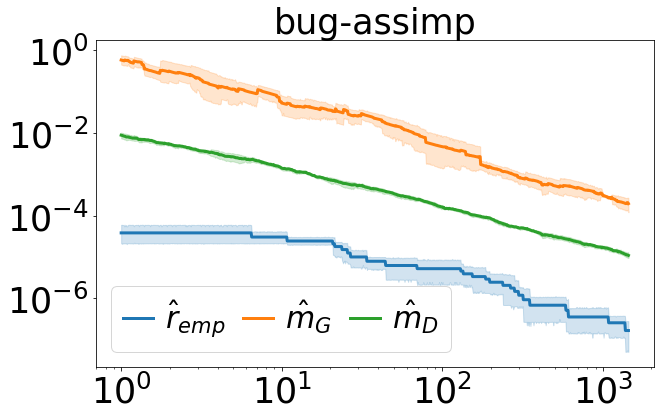

subject: bug-file, plot figures...


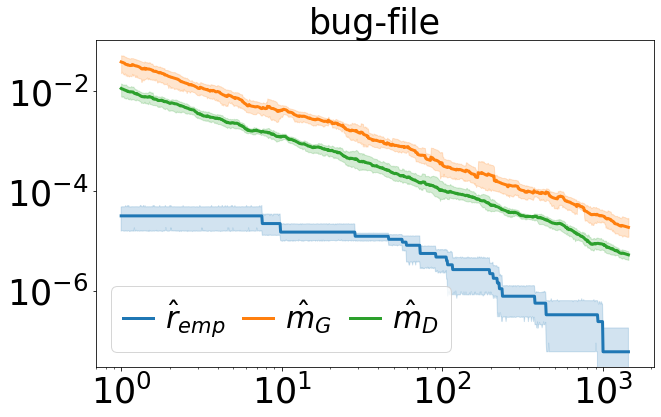

subject: bug-harfbuzz, plot figures...


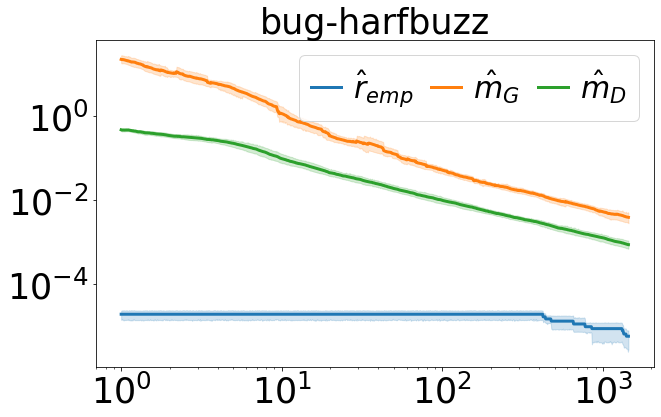

subject: bug-libxml2, plot figures...


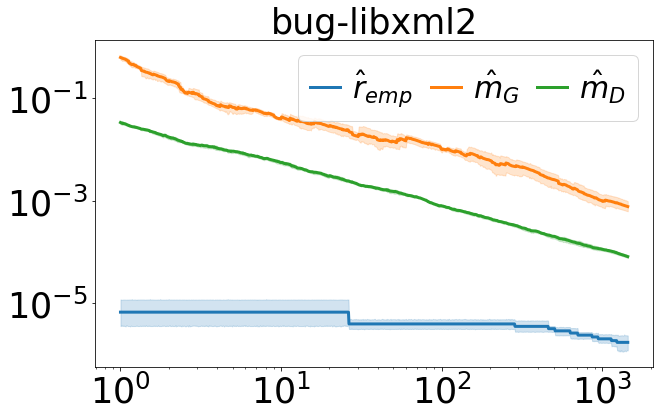

In [24]:
draw_figure = True
if draw_figure:
    for subject in subjects:
        plot_df = pd.read_csv(
            os.path.join(directory, "records/", f"{subject}.csv")
        )
        print(f"subject: {subject}, plot figures...")
        plot_df["Esti"] = plot_df["Esti"].replace(
            {
                r"$\hat{m}_{bug}$": r"$\hat{r}_{emp}$",
                r"$\hat{m}_{GT}$": r"$\hat{m}_{G}$",
                r"$\hat{m}_{St}$": r"$\hat{m}_{D}$",
            }
        )

        # Probability plot
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.lineplot(
            x=plot_df["time"].values,
            y=plot_df["Pr"].values,
            hue=plot_df["Esti"].values,
            data=plot_df,
            ax=ax,
            linewidth=3,
        )
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.tick_params(axis="both", labelsize=35)
        ax.get_legend().remove()
        ax.set_title(subject, fontsize=35)
        ax.legend(
            fontsize=30,
            handlelength=1,
            handletextpad=0.4,
            columnspacing=0.6,
            ncol=3,
        )
        plt.savefig(
            os.path.join(fig_dir, f"rr_{subject}.pdf"),
            bbox_inches="tight",
        )
        plt.show()